### Discutere la minimizzazione della funzione di Rosenbrock: f(x,y)=100(y−x^2)^2 +(1−x)^2 (che ha un minimo globale in (1,1)) utilizzando il metodo del gradiente con passo sia fisso che variabile calcolato con algoritmo di backtracking. Discutere i grafici dell’errore, del valore della funzione e della norma del gradiente al variare delle iterazioni

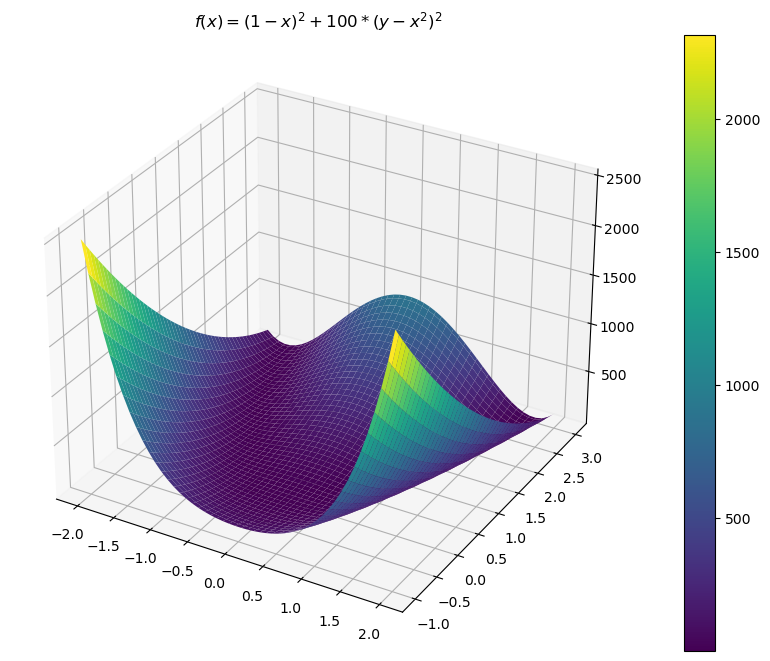


Metodo gradiente passo fisso:
Iterazioni totali =  1000

Last guess: x = (0.482604,0.230313)
Norma errore: 0.9274246171834808

Metodo gradiente backtracking:
alpha= 0.0021484375
alpha= 0.004296875
alpha= 0.0021484375
alpha= 0.0021484375
alpha= 0.55
alpha= 0.004296875
alpha= 0.275
alpha= 0.0021484375
alpha= 0.06875
alpha= 0.0021484375
alpha= 0.275
alpha= 0.0021484375
alpha= 0.0021484375
alpha= 0.004296875
alpha= 0.004296875
alpha= 0.0021484375
alpha= 0.0171875
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.004296875
alpha= 0.004296875
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.00859375
alpha= 0.0021484375
alpha= 0.004296875
alpha= 0.004296875
a

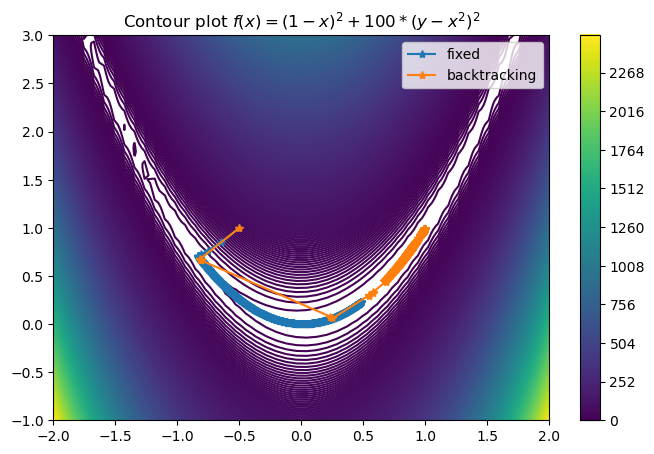

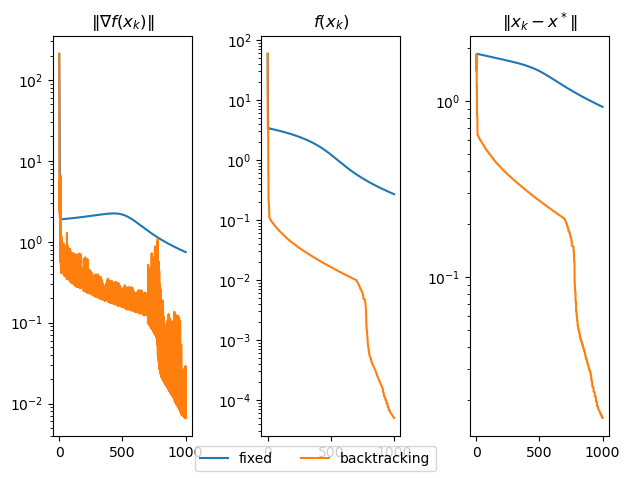

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def next_step(x,grad): 
  alpha=1.1
  rho = 0.5
  c1 = 0.25 
  p=-grad
  j=0
  jmax=10
    
  while ((f(x+alpha*p) > f(x)+c1*alpha*np.dot(grad,p)) and j<jmax ):
    alpha= rho*alpha
    j+=1
    
  if (j>jmax):
    return -1
  else:
    print('alpha=',alpha)
    return alpha


def minimize(f,grad_f,x0,step,maxit,tol,xTrue,fixed=True): 
  x_list=np.zeros((2,maxit+1))

  norm_grad_list=np.zeros(maxit+1)
  function_eval_list=np.zeros(maxit+1)
  error_list=np.zeros(maxit+1)
  
  x_last = x0

  x_list[:,0] = x_last
  
  k=0

  function_eval_list[k]=f(x0)
  error_list[k]=np.linalg.norm(x_last-xTrue)
  norm_grad_list[k]=np.linalg.norm(grad_f(x0))

  while (np.linalg.norm(grad_f(x_last))>tol and k < maxit ):
    k=k+1
    grad = grad_f(x_last)
    
    
    if not fixed:
        step = next_step(x_last, grad)
    
    if(step==-1):
      print('non convergente')
      return (k) 

    x_last=x_last-step*grad
    
    x_list[:,k] = x_last

    function_eval_list[k]=f(x_last)
    error_list[k]=np.linalg.norm(x_last-xTrue)
    norm_grad_list[k]=np.linalg.norm(grad_f(x_last))

  function_eval_list = function_eval_list[:k+1]
  error_list = error_list[:k+1]
  norm_grad_list = norm_grad_list[:k+1]
  
  print("Iterazioni totali = ",k)
  print('\nLast guess: x = (%f,%f)'%(x_list[0,k],x_list[1,k]))
 
  return (x_last,norm_grad_list, function_eval_list, error_list, x_list, k)



def f(vec):
    x, y = vec
    fout = 100*(y-x**2)**2+(1-x)**2
    return fout

def grad_f(vec):
    x, y = vec
    dfdx = 200*(y-x**2)*(-2*x)-2*(1-x)
    dfdy = 200*(y-x**2)
    return np.array([dfdx,dfdy])
    
x = np.linspace(-2, 2, 50)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
vec = np.array([X,Y])
Z=f(vec)


fig = plt.figure(figsize=(15, 8))

ax = plt.axes(projection='3d')
ax.set_title('$f(x)=(1-x)^2+100*(y-x^2)^2$')
s = ax.plot_surface(X, Y, Z, cmap='viridis')
fig.colorbar(s)
plt.show()

fig = plt.figure(figsize=(8, 5))
contours = plt.contour(X, Y, Z, levels=1000)
plt.title('Contour plot $f(x)=(1-x)^2+100*(y-x^2)^2$')
fig.colorbar(contours)


step = 0.001
maxitS= 1000
tol=1.e-5
x0 = np.array([-0.5, 1]) 
xTrue = np.array([1, 1])

print("\nMetodo gradiente passo fisso:")

(x_last,norm_grad_listf, function_eval_listf, error_listf, xlist, k)= minimize(f,grad_f,x0,step,maxitS,tol,xTrue,fixed=True)
print("Norma errore:", np.linalg.norm(x_last-xTrue, 2))
plt.plot(xlist[0, :k], xlist[1, :k],'*-')


print("\nMetodo gradiente backtracking:")


(x_last,norm_grad_list, function_eval_list, error_list, xlist, k)= minimize(f,grad_f,x0,step,maxitS,tol,xTrue,fixed=False)
print("Norma errore:", np.linalg.norm(x_last-xTrue, 2))
plt.plot(xlist[0, :k], xlist[1, :k],'*-')
plt.legend(['fixed', 'backtracking'])

plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.semilogy(norm_grad_listf)
ax1.semilogy(norm_grad_list)
ax1.set_title('$\|\\nabla f(x_k)\|$')
ax2.semilogy(function_eval_listf)
ax2.semilogy(function_eval_list)
ax2.set_title('$f(x_k)$')
ax3.semilogy(error_listf)
ax3.semilogy(error_list)
ax3.set_title('$\|x_k-x^*\|$')
fig.legend(['fixed', 'backtracking'], loc='lower center', ncol=4)
fig.tight_layout()
plt.show()